# Data Science Journey 2026 — Step 2: Master SQL for Data Science
### @datasciencehorizon | datasciencehorizon.com
**Learn · Implement · Grow**

---

In this notebook you will learn how to query a real SQLite database directly inside Jupyter — **no MySQL Workbench needed.**

**Database:** Classic Rock Songs — 1,650 songs, 37,673 radio play records

**Topics covered:**
- Connect to SQLite database with Python
- SELECT, FROM, WHERE, GROUP BY, HAVING, ORDER BY, LIMIT
- JOIN two tables
- Real-world business questions answered with SQL

> 📁 Download `classic_rock.db` from GitHub and place it in the same folder as this notebook.

---
## Step 0 — Import Libraries

In [1]:
import sqlite3      # Built-in Python library — no installation needed
import pandas as pd # For displaying results as clean DataFrames

print('Libraries imported successfully!')
print('SQLite3 version:', sqlite3.sqlite_version)

Libraries imported successfully!
SQLite3 version: 3.40.1


---
## Step 1 — Connect to the Database

SQLite3 is a **built-in Python library** — you do not need to install anything.
It connects directly to a `.db` file on your computer.

In [2]:
# Connect to the Classic Rock database
conn = sqlite3.connect('classic_rock.db')
print('✅ Connected to classic_rock.db successfully!')

✅ Connected to classic_rock.db successfully!


---
## Step 2 — Explore the Database Structure

Before querying, always explore what tables exist.

In [3]:
# See all tables in the database
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(query, conn)
print('Tables in the database:')
print(tables)

Tables in the database:
         name
0  rock_songs
1  rock_plays


In [4]:
# Check the structure of rock_songs table
query = "PRAGMA table_info(rock_songs);"
schema = pd.read_sql_query(query, conn)
print('rock_songs table columns:')
print(schema[['name', 'type']])

rock_songs table columns:
           name     type
0          Song     TEXT
1        Artist     TEXT
2  Release_Year     REAL
3     PlayCount  INTEGER


In [5]:
# Check the structure of rock_plays table
query = "PRAGMA table_info(rock_plays);"
schema = pd.read_sql_query(query, conn)
print('rock_plays table columns:')
print(schema[['name', 'type']])

rock_plays table columns:
            name       type
0       SONG RAW       TEXT
1     Song Clean       TEXT
2     ARTIST RAW       TEXT
3   ARTIST CLEAN       TEXT
4       CALLSIGN       TEXT
5           TIME    INTEGER
6      UNIQUE_ID       TEXT
7       COMBINED       TEXT
8         First?    INTEGER
9      date_time  TIMESTAMP
10   day_of_week    INTEGER


---
## Step 3 — SELECT: Retrieve Your First Data

**Syntax:** `SELECT columns FROM table LIMIT n;`

Always use `LIMIT` when exploring a new table — databases can have millions of rows.

In [6]:
# Get first 10 songs — always start with LIMIT when exploring
query = """
SELECT Song, Artist, Release_Year, PlayCount 
FROM rock_songs 
LIMIT 10;
"""
df = pd.read_sql_query(query, conn)
print(f'Total columns: {df.shape[1]}, Rows shown: {df.shape[0]}')
df

Total columns: 4, Rows shown: 10


,Song,Artist,Release_Year,PlayCount
0,Caught Up in You,.38 Special,1982.0,82
1,Hold On Loosely,.38 Special,1981.0,85
2,Rockin' Into the Night,.38 Special,1980.0,18
3,Art For Arts Sake,10cc,1975.0,1
4,Kryptonite,3 Doors Down,2000.0,13
5,Loser,3 Doors Down,2000.0,1
6,When I'm Gone,3 Doors Down,2002.0,6
7,What's Up?,4 Non Blondes,1992.0,3
8,Take On Me,a-ha,1985.0,1
9,Back In Black,AC/DC,1980.0,97


In [7]:
# How many total songs are in the database?
query = "SELECT COUNT(*) AS Total_Songs FROM rock_songs;"
df = pd.read_sql_query(query, conn)
print('Total songs in database:', df['Total_Songs'][0])

Total songs in database: 1650


---
## Step 4 — WHERE: Filter Your Data

**Syntax:** `SELECT columns FROM table WHERE condition;`

WHERE filters rows before they are returned.

In [8]:
# Business Question: Which songs were released after 1990?
query = """
SELECT Song, Artist, Release_Year, PlayCount
FROM rock_songs
WHERE Release_Year > 1990
ORDER BY Release_Year ASC;
"""
df = pd.read_sql_query(query, conn)
print(f'Songs released after 1990: {len(df)}')
df

Songs released after 1990: 184


,Song,Artist,Release_Year,PlayCount
0,More Than Words,Extreme,1991.0,1
1,Civil War,Guns N' Roses,1991.0,1
2,November Rain,Guns N' Roses,1991.0,13
3,Right Here Right Now,Jesus Jones,1991.0,3
4,Ordinary Average Guy,Joe Walsh,1991.0,2
...,...,...,...,...
179,Doom And Gloom,Rolling Stones,2012.0,1
180,Lightning Bolt,Pearl Jam,2013.0,4
181,Sirens,Pearl Jam,2013.0,3
182,Dog On A Leash,Adelitas Way,2014.0,4


In [9]:
# Business Question: Find all songs by Led Zeppelin
query = """
SELECT Song, Release_Year, PlayCount
FROM rock_songs
WHERE Artist = 'Led Zeppelin'
ORDER BY PlayCount DESC;
"""
df = pd.read_sql_query(query, conn)
print(f'Led Zeppelin songs found: {len(df)}')
df

Led Zeppelin songs found: 68


,Song,Release_Year,PlayCount
0,Black Dog,1971.0,105
1,Over the Hills and Far Away,1973.0,94
2,Rock and Roll,1971.0,92
3,Ramble On,1969.0,90
4,D'Yer Mak'er,1973.0,88
...,...,...,...
63,TANGERINE,1970.0,1
64,That's the Way,1970.0,1
65,The Crunge,1973.0,1
66,THE WANTON SONG,1975.0,1


In [10]:
# Multiple conditions with AND
# Business Question: Songs from the 1970s with more than 100 plays
query = """
SELECT Song, Artist, Release_Year, PlayCount
FROM rock_songs
WHERE Release_Year >= 1970 
  AND Release_Year < 1980
  AND PlayCount > 100
ORDER BY PlayCount DESC
LIMIT 10;
"""
df = pd.read_sql_query(query, conn)
print('Top 10 most played 1970s songs (100+ plays):')
df

Top 10 most played 1970s songs (100+ plays):


,Song,Artist,Release_Year,PlayCount
0,Dream On,Aerosmith,1973.0,142
1,Sweet Emotion,Aerosmith,1975.0,141
2,More Than a Feeling,Boston,1976.0,134
3,Carry On Wayward Son,Kansas,1976.0,134
4,Peace of Mind,Boston,1976.0,132
5,Crazy On You,Heart,1976.0,125
6,Rock And Roll All Nite,Kiss,1975.0,119
7,Bohemian Rhapsody,Queen,1975.0,119
8,Renegade,Styx,1978.0,116
9,Magic Man,Heart,1976.0,115


---
## Step 5 — GROUP BY: Aggregate Your Data

**Syntax:** `SELECT column, AGG_FUNC(col) FROM table GROUP BY column;`

GROUP BY groups rows with the same value so you can apply aggregate functions:
- `COUNT()` — count rows
- `SUM()` — total
- `AVG()` — average
- `MAX()` / `MIN()` — highest / lowest

In [11]:
# Business Question: Top 10 most played artists of all time
query = """
SELECT Artist,
       SUM(PlayCount)  AS Total_Plays,
       COUNT(*)        AS Number_of_Songs,
       AVG(PlayCount)  AS Avg_Plays_Per_Song
FROM rock_songs
GROUP BY Artist
ORDER BY Total_Plays DESC
LIMIT 10;
"""
df = pd.read_sql_query(query, conn)
df['Avg_Plays_Per_Song'] = df['Avg_Plays_Per_Song'].round(1)
print('Top 10 Classic Rock Artists by Total Play Count:')
df

Top 10 Classic Rock Artists by Total Play Count:


,Artist,Total_Plays,Number_of_Songs,Avg_Plays_Per_Song
0,Led Zeppelin,1546,68,22.7
1,Rolling Stones,1112,47,23.7
2,Van Halen,1055,27,39.1
3,Pink Floyd,1044,39,26.8
4,Tom Petty & The Heartbreakers,916,18,50.9
5,AC/DC,762,20,38.1
6,Aerosmith,733,25,29.3
7,The Beatles,700,96,7.3
8,Queen,693,18,38.5
9,ZZ Top,667,15,44.5


In [12]:
# Business Question: How many songs were released per decade?
query = """
SELECT (CAST(Release_Year / 10 AS INTEGER) * 10) AS Decade,
       COUNT(*) AS Number_of_Songs,
       SUM(PlayCount) AS Total_Plays
FROM rock_songs
WHERE Release_Year IS NOT NULL
GROUP BY Decade
ORDER BY Decade;
"""
df = pd.read_sql_query(query, conn)
print('Classic Rock Songs by Decade:')
df

Classic Rock Songs by Decade:


,Decade,Number_of_Songs,Total_Plays
0,1950,2,3
1,1960,264,3587
2,1970,706,17894
3,1980,472,10579
4,1990,161,1350
5,2000,33,99
6,2010,12,36


---
## Step 6 — HAVING: Filter After Grouping

**Key difference:**
- `WHERE` filters rows **before** grouping
- `HAVING` filters groups **after** GROUP BY

You cannot use WHERE with aggregate functions like SUM() or COUNT(). Use HAVING instead.

In [13]:
# Business Question: Which artists have more than 500 total plays?
# Cannot use WHERE here because SUM() is an aggregate function
query = """
SELECT Artist, 
       SUM(PlayCount) AS Total_Plays,
       COUNT(*) AS Songs
FROM rock_songs
GROUP BY Artist
HAVING Total_Plays > 500
ORDER BY Total_Plays DESC;
"""
df = pd.read_sql_query(query, conn)
print(f'Artists with more than 500 total plays: {len(df)}')
df

Artists with more than 500 total plays: 18


,Artist,Total_Plays,Songs
0,Led Zeppelin,1546,68
1,Rolling Stones,1112,47
2,Van Halen,1055,27
3,Pink Floyd,1044,39
4,Tom Petty & The Heartbreakers,916,18
5,AC/DC,762,20
6,Aerosmith,733,25
7,The Beatles,700,96
8,Queen,693,18
9,ZZ Top,667,15


---
## Step 7 — ORDER BY and LIMIT

**ORDER BY** sorts results — ASC (low to high) or DESC (high to low)

**LIMIT** restricts the number of rows returned

**OFFSET** skips a number of rows — useful for pagination

In [14]:
# Top 5 highest play count songs
query = """
SELECT Song, Artist, Release_Year, PlayCount
FROM rock_songs
ORDER BY PlayCount DESC
LIMIT 5;
"""
df = pd.read_sql_query(query, conn)
print('Top 5 Most Played Songs:')
df

Top 5 Most Played Songs:


,Song,Artist,Release_Year,PlayCount
0,Dream On,Aerosmith,1973.0,142
1,Sweet Emotion,Aerosmith,1975.0,141
2,All Along the Watchtower,Jimi Hendrix,1968.0,141
3,You Shook Me All Night Long,AC/DC,1980.0,138
4,More Than a Feeling,Boston,1976.0,134


In [15]:
# OFFSET example: Get songs ranked 6 to 10 (skip first 5)
query = """
SELECT Song, Artist, PlayCount
FROM rock_songs
ORDER BY PlayCount DESC
LIMIT 5 OFFSET 5;
"""
df = pd.read_sql_query(query, conn)
print('Songs ranked 6 to 10 by play count:')
df

Songs ranked 6 to 10 by play count:


,Song,Artist,PlayCount
0,Carry On Wayward Son,Kansas,134
1,Peace of Mind,Boston,132
2,Crazy On You,Heart,125
3,Legs,ZZ Top,121
4,Sharp Dressed Man,ZZ Top,120


---
## Step 8 — JOIN: Combine Two Tables

**Syntax:** `SELECT columns FROM table1 JOIN table2 ON table1.col = table2.col;`

JOIN combines rows from two or more tables based on a related column.

- **INNER JOIN** — only rows that match in both tables
- **LEFT JOIN** — all rows from left table + matching rows from right

In [16]:
# Business Question: Which songs appear most in radio plays?
# Join rock_songs with rock_plays
query = """
SELECT s.Song,
       s.Artist,
       s.Release_Year,
       COUNT(p.UNIQUE_ID) AS Radio_Play_Count
FROM rock_songs s
INNER JOIN rock_plays p ON s.Song = p."Song Clean"
GROUP BY s.Song, s.Artist
ORDER BY Radio_Play_Count DESC
LIMIT 10;
"""
df = pd.read_sql_query(query, conn)
print('Top 10 Most Radio-Played Classic Rock Songs:')
df

Top 10 Most Radio-Played Classic Rock Songs:


,Song,Artist,Release_Year,Radio_Play_Count
0,Dream On,Aerosmith,1973.0,142
1,All Along the Watchtower,Jimi Hendrix,1968.0,141
2,Sweet Emotion,Aerosmith,1975.0,141
3,You Shook Me All Night Long,AC/DC,1980.0,138
4,Carry On Wayward Son,Kansas,1976.0,134
5,Come Together,The Beatles,1969.0,134
6,More Than a Feeling,Boston,1976.0,134
7,Peace of Mind,Boston,1976.0,132
8,Crazy On You,Heart,1976.0,125
9,Legs,ZZ Top,1983.0,121


In [17]:
# Business Question: Which radio stations play the most classic rock?
query = """
SELECT CALLSIGN AS Radio_Station,
       COUNT(*) AS Total_Plays
FROM rock_plays
GROUP BY CALLSIGN
ORDER BY Total_Plays DESC
LIMIT 10;
"""
df = pd.read_sql_query(query, conn)
print('Top 10 Classic Rock Radio Stations:')
df

Top 10 Classic Rock Radio Stations:


,Radio_Station,Total_Plays
0,KSEG,1821
1,WXGL,1797
2,WCSX,1789
3,KGLK,1744
4,KUFX,1742
5,WLUP,1726
6,KZPS,1685
7,WBIG,1654
8,KGB,1650
9,WMGK,1639


In [18]:
# Business Question: On which day of the week is classic rock played most?
# day_of_week: 0=Monday, 1=Tuesday ... 6=Sunday
query = """
SELECT 
    CASE day_of_week
        WHEN 0 THEN 'Monday'
        WHEN 1 THEN 'Tuesday'
        WHEN 2 THEN 'Wednesday'
        WHEN 3 THEN 'Thursday'
        WHEN 4 THEN 'Friday'
        WHEN 5 THEN 'Saturday'
        WHEN 6 THEN 'Sunday'
    END AS Day_of_Week,
    COUNT(*) AS Total_Plays
FROM rock_plays
GROUP BY day_of_week
ORDER BY Total_Plays DESC;
"""
df = pd.read_sql_query(query, conn)
print('Classic Rock Plays by Day of Week:')
df

Classic Rock Plays by Day of Week:


,Day_of_Week,Total_Plays
0,Wednesday,5842
1,Thursday,5814
2,Monday,5775
3,Friday,5582
4,Saturday,5531
5,Sunday,5031
6,Tuesday,4098


---
## Step 9 — Bonus: SQL + Matplotlib Together

The real power of SQLite3 in Python: query with SQL, then visualise with Matplotlib.

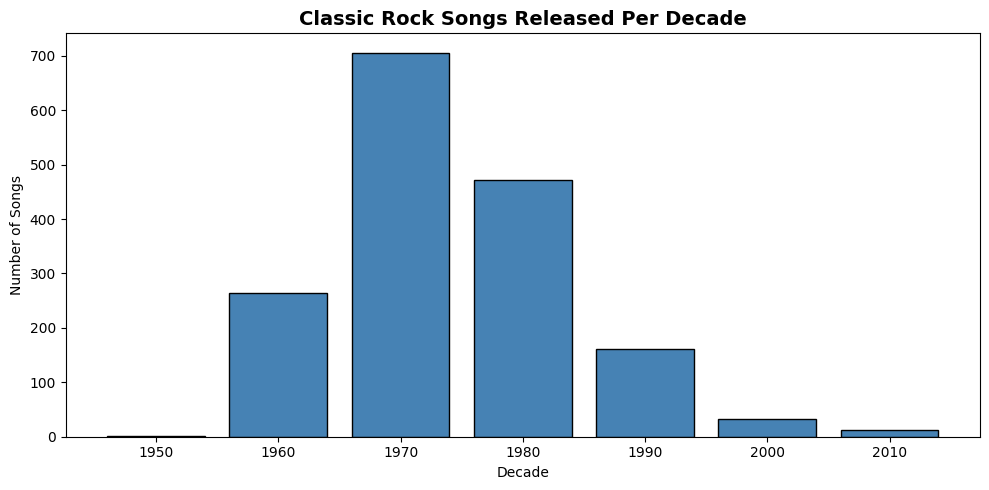

Chart saved!


In [19]:
import matplotlib.pyplot as plt

# Get songs per decade using SQL
query = """
SELECT (CAST(Release_Year / 10 AS INTEGER) * 10) AS Decade,
       COUNT(*) AS Songs
FROM rock_songs
WHERE Release_Year IS NOT NULL
GROUP BY Decade
ORDER BY Decade;
"""
df = pd.read_sql_query(query, conn)

# Visualise with Matplotlib
plt.figure(figsize=(10, 5))
plt.bar(df['Decade'].astype(str), df['Songs'], color='steelblue', edgecolor='black')
plt.title('Classic Rock Songs Released Per Decade', fontsize=14, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Number of Songs')
plt.tight_layout()
plt.savefig('songs_per_decade.png', dpi=150)
plt.show()
print('Chart saved!')

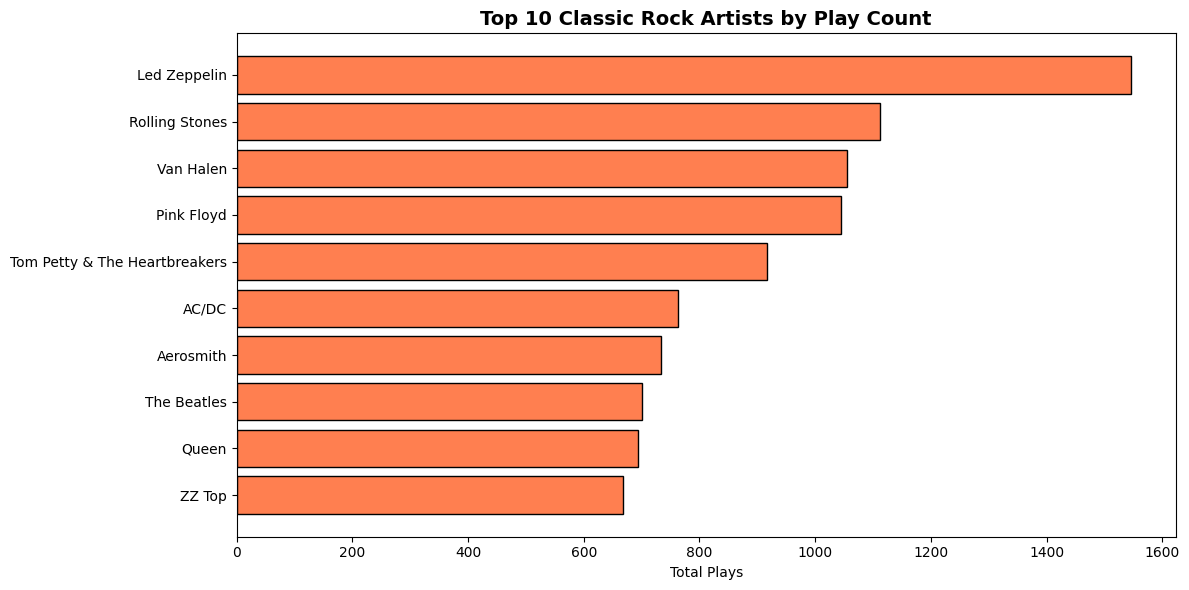

Chart saved!


In [20]:
# Top 10 artists bar chart
query = """
SELECT Artist, SUM(PlayCount) AS Total_Plays
FROM rock_songs
GROUP BY Artist
ORDER BY Total_Plays DESC
LIMIT 10;
"""
df = pd.read_sql_query(query, conn)

plt.figure(figsize=(12, 6))
plt.barh(df['Artist'][::-1], df['Total_Plays'][::-1], color='coral', edgecolor='black')
plt.title('Top 10 Classic Rock Artists by Play Count', fontsize=14, fontweight='bold')
plt.xlabel('Total Plays')
plt.tight_layout()
plt.savefig('top_artists.png', dpi=150)
plt.show()
print('Chart saved!')

---
## Step 10 — Always Close Your Connection

In [21]:
# Always close the connection when you are done
conn.close()
print('✅ Database connection closed.')

✅ Database connection closed.


---
## SQL Commands Summary

| Command | Purpose | Example |
|---|---|---|
| SELECT | Choose columns | SELECT Song, Artist |
| FROM | Choose table | FROM rock_songs |
| WHERE | Filter rows | WHERE Release_Year > 1970 |
| GROUP BY | Group rows | GROUP BY Artist |
| HAVING | Filter groups | HAVING SUM(PlayCount) > 500 |
| ORDER BY | Sort results | ORDER BY PlayCount DESC |
| LIMIT | Limit rows | LIMIT 10 |
| OFFSET | Skip rows | OFFSET 5 |
| JOIN | Combine tables | JOIN rock_plays ON Song |

---

## Your SQL Learning Roadmap

1. ✅ SELECT, FROM, WHERE — **done in this notebook**
2. ✅ GROUP BY, HAVING, ORDER BY — **done in this notebook**
3. ✅ LIMIT, OFFSET — **done in this notebook**
4. ✅ JOIN — **done in this notebook**

Follow **@datasciencehorizon** | datasciencehorizon.com

*Learn · Implement · Grow*